Feature Transformation
----

Feature Transformation is the process of changing or converting the existing features (columns) in a dataset into a more suitable format so that machine learning models can understand the data better and produce better predictions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import PowerTransformer
import numpy as np
import seaborn as sns

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Normalization (Min-Max Scaling)
----

Normalization scales feature values into a fixed range, usually between 0 and 1.

Use Normalization when:
--

Features have different ranges.
You want all values within a fixed range such as 0 to 1.
The algorithm is sensitive to the magnitude of features.

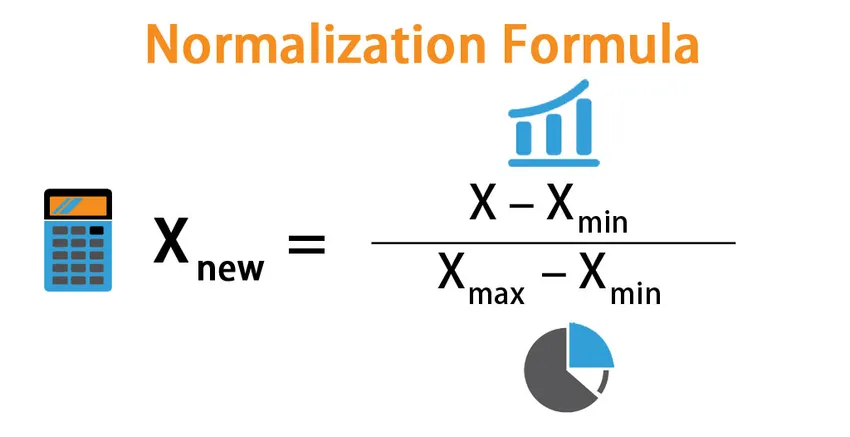

In [2]:
df = pd.read_csv("student_performance.csv")

In [3]:
df

,Student,Age,Study_Hours,Attendance_Percentage,Test_Score
0,Aarav,16,2,80,65
1,Priya,17,4,90,78
2,Rohan,18,6,60,70
3,Isha,17,3,85,75
4,Dev,19,1,50,60


In [4]:
features = ["Age", "Study_Hours", "Attendance_Percentage", "Test_Score"]
X = df[features]

In [5]:
X.columns

Index(['Age', 'Study_Hours', 'Attendance_Percentage', 'Test_Score'], dtype='str')

In [6]:
min_max_scaler = MinMaxScaler()
X_normalized = pd.DataFrame(min_max_scaler.fit_transform(X), columns=[f"{col}_Norm" for col in X.columns])

In [7]:
X_normalized

,Age_Norm,Study_Hours_Norm,Attendance_Percentage_Norm,Test_Score_Norm
0,0.000000,0.2,0.750,0.277778
1,0.333333,0.6,1.000,1.000000
2,0.666667,1.0,0.250,0.555556
3,0.333333,0.4,0.875,0.833333
4,1.000000,0.0,0.000,0.000000


Standardization (Z-Score Normalization)
----

Standardization transforms data so that:

Mean = 0
Standard Deviation = 1


Use Standardization when:
--
Features have different scales.

The algorithm is affected by feature magnitude.

You want to center the data around 0.


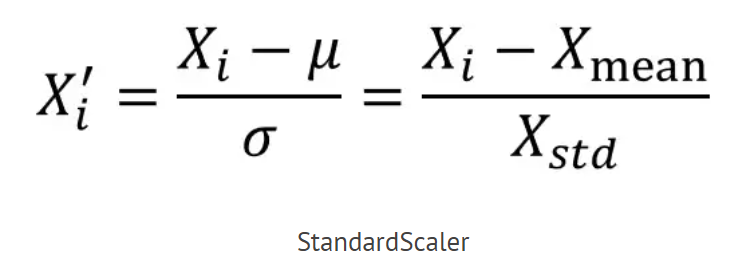

In [9]:
standard_scaler = StandardScaler()
X_standardized = pd.DataFrame(standard_scaler.fit_transform(X), columns=[f"{col}_Std" for col in X.columns])

In [10]:
X_standardized 

,Age_Std,Study_Hours_Std,Attendance_Percentage_Std,Test_Score_Std
0,-1.372813,-0.697486,0.455661,-0.704448
1,-0.392232,0.464991,1.106606,1.286384
2,0.588348,1.627467,-0.846228,0.061256
3,-0.392232,-0.116248,0.781133,0.826961
4,1.568929,-1.278724,-1.497172,-1.470153


In [11]:
X_standardized['Study_Hours_Std'].mean()

np.float64(-1.3322676295501878e-16)

Original vs normalized vs standardized for Age
----

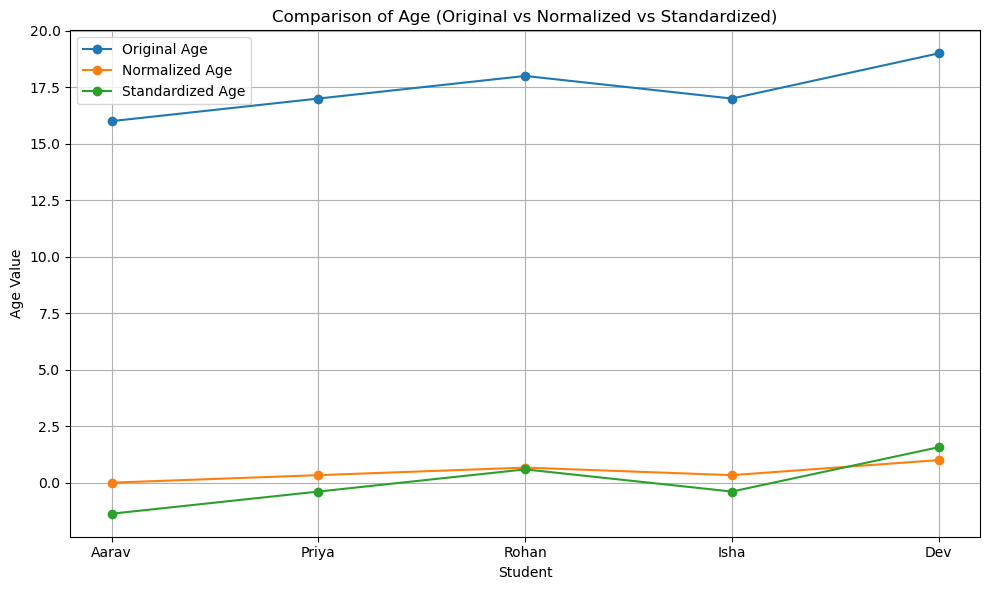

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(df["Student"], df["Age"], marker='o', label='Original Age')
plt.plot(df["Student"], X_normalized["Age_Norm"], marker='o', label='Normalized Age')
plt.plot(df["Student"], X_standardized["Age_Std"], marker='o', label='Standardized Age')

plt.title("Comparison of Age (Original vs Normalized vs Standardized)")
plt.xlabel("Student")
plt.ylabel("Age Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Power Transformation (Box-Cox, Yeo-Johnson)
----

Both are feature transformation techniques used to make skewed data more normally distributed and reduce the effect of skewness.


Box-Cox Transformation
---

Use Box-Cox when your data contains only positive values.

Condition:

All values must be greater than 0

Yeo-Johnson Transformation
---

Use Yeo-Johnson when your data contains:

Positive values

Zero values

Negative values

In [10]:
df = pd.read_csv('power_transform.csv')

In [11]:
df

,Income,Debt,Net_Worth
0,23463.404499,-9102.381941,27647.430841
1,150506.071546,-8509.856889,145128.059396
2,65837.284677,-71015.174226,-11242.923431
3,45647.127689,-8612.315657,41593.853984
4,8481.243523,-9521.555270,-5631.214849
...,...,...,...
1995,53494.705031,-17507.644603,30695.050330
1996,156881.639298,-12212.044824,135976.724604
1997,3572.545375,-15054.604616,-11590.730611
1998,2937.351341,-22646.885444,-18336.009309


<Axes: xlabel='Income', ylabel='Count'>

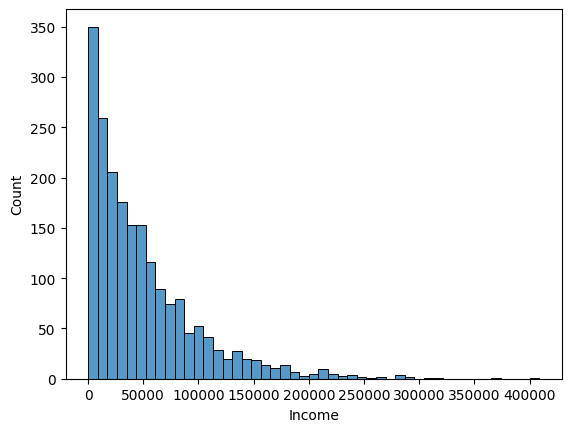

In [12]:
sns.histplot(df['Income'])

In [13]:
positive_features = ['Income'] 
all_features = ['Income', 'Debt', 'Net_Worth']  

boxcox
---

In [14]:
boxcox = PowerTransformer(method='box-cox')
df_boxcox = pd.DataFrame(boxcox.fit_transform(df[positive_features]), columns=[f"{col}_boxcox" for col in positive_features])

<Axes: ylabel='Count'>

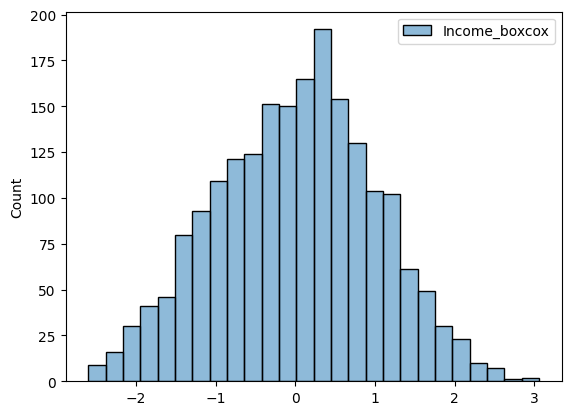

In [15]:
sns.histplot(df_boxcox)

yeojohnson
-----

In [16]:
yeojohnson = PowerTransformer(method='yeo-johnson')
df_yeojohnson = pd.DataFrame(yeojohnson.fit_transform(df[all_features]), columns=[f"{col}_yeojohnson" for col in all_features])

<Axes: xlabel='Net_Worth_yeojohnson', ylabel='Count'>

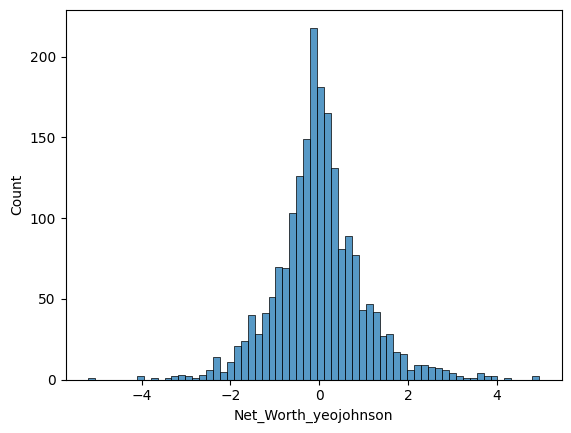

In [20]:
sns.histplot(df_yeojohnson['Net_Worth_yeojohnson'])

<Axes: xlabel='Income_boxcox', ylabel='Count'>

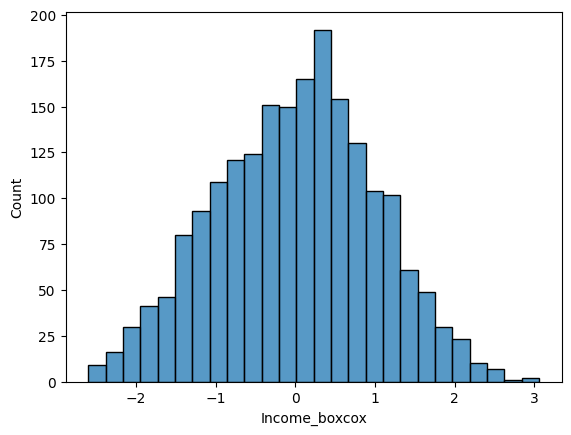

In [19]:
sns.histplot(df_boxcox['Income_boxcox'])

<Axes: xlabel='Debt_yeojohnson', ylabel='Count'>

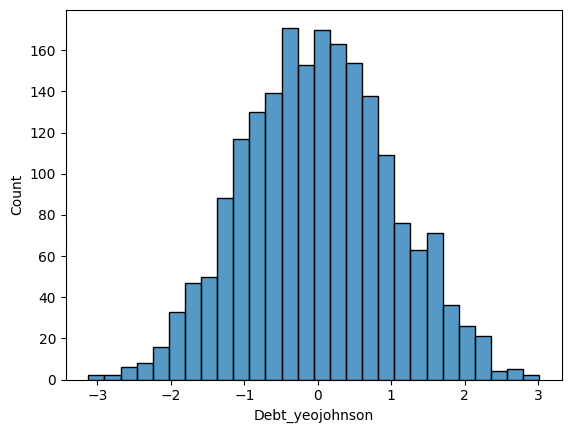

In [18]:
sns.histplot(df_yeojohnson['Debt_yeojohnson'])

Binning (Discretization)
---

Binning converts continuous variables into discrete bins (intervals).

Why Use It:

- Reduces the effect of minor observation errors.
- Converts continuous data into categorical for specific algorithms.



In [21]:
df = pd.read_csv("customer_income.csv")

df.head()

,Customer_ID,Name,Age,Monthly_Income,Annual_Spending
0,1,Amit,18,12000,8000
1,2,Priya,21,18000,12000
2,3,Rahul,23,22000,15000
3,4,Neha,25,28000,18000
4,5,Rohan,27,32000,22000


In [22]:
bins = [0, 20, 30, 40, 50, 100]

labels = ["Teen", "Young Adult", "Adult", "Middle Age", "Senior"]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

In [23]:
df

,Customer_ID,Name,Age,Monthly_Income,Annual_Spending,Age_Group
0,1,Amit,18,12000,8000,Teen
1,2,Priya,21,18000,12000,Young Adult
2,3,Rahul,23,22000,15000,Young Adult
3,4,Neha,25,28000,18000,Young Adult
4,5,Rohan,27,32000,22000,Young Adult
5,6,Pooja,29,38000,26000,Young Adult
6,7,Vikas,31,42000,30000,Adult
7,8,Sneha,33,48000,34000,Adult
8,9,Arjun,35,55000,40000,Adult
9,10,Kavita,37,62000,45000,Adult


In [24]:
income_bins = [0, 30000, 60000, 100000, float("inf")]

income_labels = [
    "Low Income",
    "Medium Income",
    "High Income",
    "Very High Income"
]

df["Income_Category"] = pd.cut(
    df["Monthly_Income"],
    bins=income_bins,
    labels=income_labels
)

In [25]:
df

,Customer_ID,Name,Age,Monthly_Income,Annual_Spending,Age_Group,Income_Category
0,1,Amit,18,12000,8000,Teen,Low Income
1,2,Priya,21,18000,12000,Young Adult,Low Income
2,3,Rahul,23,22000,15000,Young Adult,Low Income
3,4,Neha,25,28000,18000,Young Adult,Low Income
4,5,Rohan,27,32000,22000,Young Adult,Medium Income
5,6,Pooja,29,38000,26000,Young Adult,Medium Income
6,7,Vikas,31,42000,30000,Adult,Medium Income
7,8,Sneha,33,48000,34000,Adult,Medium Income
8,9,Arjun,35,55000,40000,Adult,Medium Income
9,10,Kavita,37,62000,45000,Adult,High Income
